# بسم الله الرحمن الرحيم

In [ ]:
!pip install opendatasets

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import opendatasets as od
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from mlxtend.plotting import plot_confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report

# Load Data

In [ ]:
od.download('https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset')

100%|██████████| 734k/734k [00:00<00:00, 116MB/s]

In [ ]:
df = pd.read_csv('/content/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
df = df.dropna()
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


# Preprocesing

In [ ]:
df = df.drop(df['gender'][df['gender'] == 'Other'].index, axis=0)

In [ ]:
for i, label in enumerate(np.unique(df['smoking_history'])):
    df['smoking_history'][df['smoking_history'] == label] = i

df['smoking_history'] = df['smoking_history'].astype('int64')

In [ ]:
for i, label in enumerate(np.unique(df['gender'])):
    df['gender'][df['gender'] == label] = i
df['gender'] = df['gender'].astype('int64')

In [ ]:
df.describe()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000
mean,0.414375,41.888076,0.074863,0.039427,2.179502,27.320757,5.527529,138.057810,0.085015
std,0.492616,22.517206,0.263172,0.194610,1.889559,6.636853,1.070665,40.709469,0.278906
min,0.000000,0.080000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,0.000000,43.000000,0.000000,0.000000,3.000000,27.320000,5.800000,140.000000,0.000000
75%,1.000000,60.000000,0.000000,0.000000,4.000000,29.580000,6.200000,159.000000,0.000000
max,1.000000,80.000000,1.000000,1.000000,5.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
scaler = MinMaxScaler()

normalized_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [ ]:
normalized_data.describe()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000
mean,0.414375,0.523124,0.074863,0.039427,0.435900,0.202040,0.368642,0.263899,0.085015
std,0.492616,0.281747,0.263172,0.194610,0.377912,0.077461,0.194666,0.185043,0.278906
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.299299,0.000000,0.000000,0.000000,0.158964,0.236364,0.090909,0.000000
50%,0.000000,0.537037,0.000000,0.000000,0.600000,0.202031,0.418182,0.272727,0.000000
75%,1.000000,0.749750,0.000000,0.000000,0.800000,0.228408,0.490909,0.359091,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# UnderSamping to solve the Unbalnced Class

In [ ]:
X = df.drop('diabetes',axis=1)
Y = df['diabetes']

In [ ]:
len(Y[Y == 0])

91482

In [ ]:
len(Y[Y == 1])

8500

In [ ]:
rus = RandomUnderSampler(random_state=2)
X_undersampled, y_undersampled = rus.fit_resample(X, Y)

In [ ]:
len(y_undersampled[y_undersampled == 0])

8500

In [ ]:
len(y_undersampled[y_undersampled == 1])

8500

# PCA (Our Recgonition System) and creating X & Y

In [ ]:
def MyPCA(X , num_components):
    X_meaned = X - np.mean(X , axis = 0)
    cov_mat = np.cov(X_meaned.astype(float), rowvar=False)
    eigen_values , eigen_vectors = np.linalg.eigh(cov_mat)

    sorted_index = np.argsort(eigen_values)[::-1]
    sorted_eigenvalue = eigen_values[sorted_index]
    sorted_eigenvectors = eigen_vectors[:,sorted_index]

    eigenvector_subset = sorted_eigenvectors[:,0:num_components]

    X_reduced = np.dot(eigenvector_subset.transpose() , X_meaned.transpose() ).transpose()

    return X_reduced

In [ ]:
PCA_X = MyPCA(X_undersampled, 6)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(PCA_X, y_undersampled, test_size=0.2)

# Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test,y_pred)

In [ ]:
print("accuracy: ", str(accuracy))

accuracy:  0.903235294117647


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1734
           1       0.90      0.91      0.90      1666

    accuracy                           0.90      3400
   macro avg       0.90      0.90      0.90      3400
weighted avg       0.90      0.90      0.90      3400



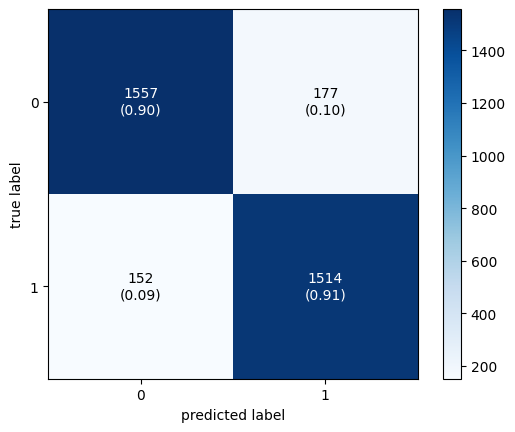

In [ ]:
fig, ax = plot_confusion_matrix(conf_mat=cm,
                                show_absolute=True,
                                show_normed=True,
                                colorbar=True)
plt.show()

# تم بحمدالله